# Assignment 3 Data preprocessing, in the right order

**Dataset source:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset
(file used: `credit_risk_dataset.csv` — one row per loan application; target `loan_status`: 0 = repaid, 1 = default)

In [3]:
import sys, subprocess
try:
    import imblearn
except ImportError:

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"], check=True)
    import imblearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, StandardScaler,
                                   MinMaxScaler, RobustScaler, PowerTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
df = pd.read_csv("credit_risk_dataset.csv")
print("shape:", df.shape)
print("\nmissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

shape: (32581, 12)

missing values per column:
person_emp_length     895
loan_int_rate        3116
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Q1. Split first (stratified, fixed `random_state`)

In [4]:
X = df.drop(columns="loan_status")
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "| test:", X_test.shape)
print("default rate  train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))

train: (26064, 11) | test: (6517, 11)
default rate  train: 0.2182 | test: 0.2182


**Why the split is the first step:** The later steps -filling gaps, scaling, encoding. They learns numbers from the data. If it learns them before the split, information from the test rows leaks into training.
The test set has to stay unseen, like future data, so the split comes before anything is fitted.

## Q2. Missing values three ways (fit on train only)

In [5]:
num_cols = ["person_age", "person_income", "person_emp_length",
            "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
cat_ohe  = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]
cat_ord  = ["loan_grade"]

train_num = X_train[num_cols]

train_drop = X_train.dropna()[num_cols]
print("rows kept after dropping:", len(train_drop), "of", len(X_train))

med = SimpleImputer(strategy="median").fit(train_num)
train_med = pd.DataFrame(med.transform(train_num), columns=num_cols, index=train_num.index)

sc = StandardScaler().fit(train_num)
knn = KNNImputer(n_neighbors=5).fit(sc.transform(train_num))
train_knn = pd.DataFrame(sc.inverse_transform(knn.transform(sc.transform(train_num))),
                         columns=num_cols, index=train_num.index)

rows = []
for col in ["loan_int_rate", "person_emp_length"]:
    for name, frame in [("observed values only", train_num.dropna(subset=[col])),
                        ("drop rows", train_drop), ("median fill", train_med), ("KNN impute", train_knn)]:
        rows.append({"column": col, "method": name, "n": frame[col].notna().sum(),
                     "mean": frame[col].mean(), "std": frame[col].std()})
pd.DataFrame(rows).round(3)

rows kept after dropping: 22882 of 26064


,column,method,n,mean,std
0,loan_int_rate,observed values only,23563,11.016,3.235
1,loan_int_rate,drop rows,22882,11.045,3.223
2,loan_int_rate,median fill,26064,11.013,3.076
3,loan_int_rate,KNN impute,26064,11.003,3.116
4,person_emp_length,observed values only,25326,4.795,4.172
5,person_emp_length,drop rows,22882,4.786,4.184
6,person_emp_length,median fill,26064,4.772,4.115
7,person_emp_length,KNN impute,26064,4.779,4.129


## Q3. Outliers in `person_age`: IQR vs z-score vs percentile capping

In [6]:
col = X_train["person_age"]

q1, q3 = col.quantile([0.25, 0.75])
iqr = q3 - q1
m_iqr = (col < q1 - 1.5 * iqr) | (col > q3 + 1.5 * iqr)

m_z = ((col - col.mean()) / col.std()).abs() > 3

lo, hi = col.quantile([0.01, 0.99])
m_pct = (col < lo) | (col > hi)

print(f"IQR rule        flags {m_iqr.sum():5d} rows  (limits {q1 - 1.5*iqr:.1f} to {q3 + 1.5*iqr:.1f})")
print(f"z-score > 3     flags {m_z.sum():5d} rows")
print(f"1st/99th pct    flags {m_pct.sum():5d} rows  (limits {lo:.1f} to {hi:.1f})")
print()
print("overlap IQR & z-score   :", (m_iqr & m_z).sum())
print("overlap IQR & percentile:", (m_iqr & m_pct).sum())
print("overlap z-score & pct   :", (m_z & m_pct).sum())
print("flagged by all three    :", (m_iqr & m_z & m_pct).sum())
print()
print("max age before capping:", col.max(), "| after capping at 99th percentile:", col.clip(lo, hi).max())

IQR rule        flags  1145 rows  (limits 12.5 to 40.5)
z-score > 3     flags   429 rows
1st/99th pct    flags   236 rows  (limits 21.0 to 50.0)

overlap IQR & z-score   : 429
overlap IQR & percentile: 224
overlap z-score & pct   : 224
flagged by all three    : 224

max age before capping: 144 | after capping at 99th percentile: 50


## Q4. Encoding: one-hot, ordinal (explicit order) and frequency

In [7]:
print("columns at the start:", X_train.shape[1])
enc_train = X_train.copy()

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[["person_home_ownership"]])
ohe_part = pd.DataFrame(ohe.transform(enc_train[["person_home_ownership"]]),
                        columns=ohe.get_feature_names_out(), index=enc_train.index)
enc_train = pd.concat([enc_train.drop(columns="person_home_ownership"), ohe_part], axis=1)
print("after one-hot encoding   :", enc_train.shape[1], "columns   (", list(ohe.categories_[0]), ")")

grade_order = ["A", "B", "C", "D", "E", "F", "G"]
ordi = OrdinalEncoder(categories=[grade_order], handle_unknown="use_encoded_value",
                      unknown_value=-1).fit(X_train[["loan_grade"]])
enc_train["loan_grade"] = ordi.transform(X_train[["loan_grade"]]).ravel()
print("after ordinal encoding   :", enc_train.shape[1], "columns   (A=0 ... G=6)")

freq_map = X_train["loan_intent"].value_counts(normalize=True)
enc_train["loan_intent"] = X_train["loan_intent"].map(freq_map)
print("after frequency encoding :", enc_train.shape[1], "columns")

enc_train[["loan_grade", "loan_intent"]].head()

columns at the start: 11
after one-hot encoding   : 14 columns   ( ['MORTGAGE', 'OTHER', 'OWN', 'RENT'] )
after ordinal encoding   : 14 columns   (A=0 ... G=6)
after frequency encoding : 14 columns


,loan_grade,loan_intent
15884,0.0,0.198665
15138,1.0,0.167971
7474,1.0,0.187769
18212,2.0,0.187769
6493,0.0,0.175414


*Note:* this dataset has no high-cardinality column, so frequency encoding is shown on `loan_intent` (6 values). The idea is the same for a column with hundreds of values.

## Q5. A category in test that never appeared in train

In [8]:
new = X_test.head(3).copy()
new["person_home_ownership"] = "SQUATTER"
new["loan_grade"] = "Z"
new["loan_intent"] = "CRYPTO"

print("one-hot  :", ohe.transform(new[["person_home_ownership"]]).tolist())
print("ordinal  :", ordi.transform(new[["loan_grade"]]).ravel().tolist())
print("frequency:", new["loan_intent"].map(freq_map).fillna(0).tolist())
print("\nno crash")

one-hot  : [[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]]
ordinal  : [-1.0, -1.0, -1.0]
frequency: [0.0, 0.0, 0.0]

no crash


## Q6. Scaling a skewed column (`person_income`)

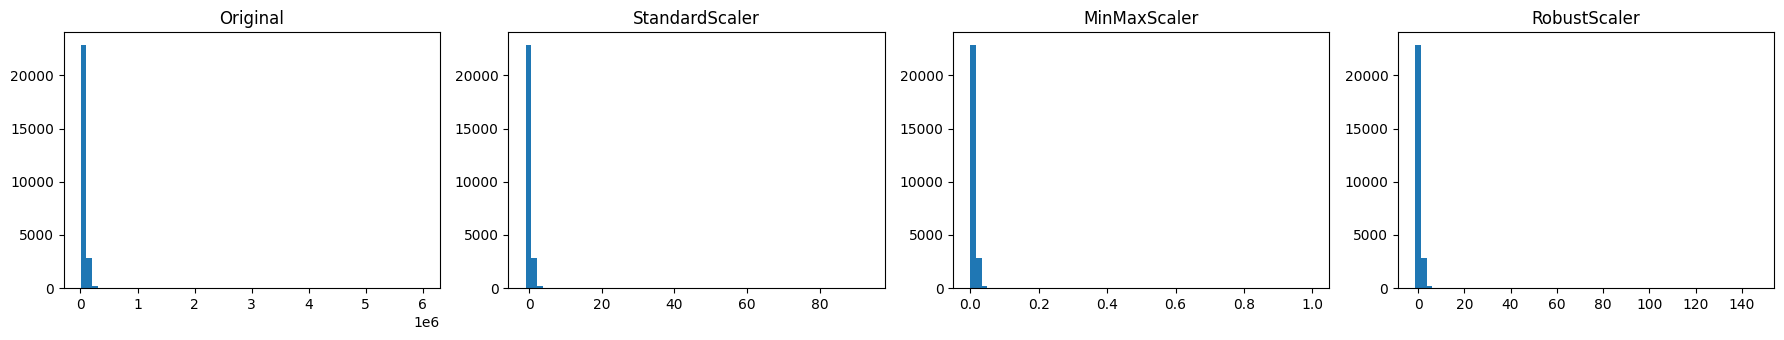

,Original,StandardScaler,MinMaxScaler,RobustScaler
count,26064.000,26064.000,26064.000,26064.000
mean,66043.498,-0.000,0.010,0.272
std,63715.995,1.000,0.011,1.571
min,4000.000,-0.974,0.000,-1.257
25%,38443.250,-0.433,0.006,-0.408
50%,55000.000,-0.173,0.009,0.000
75%,79000.000,0.203,0.013,0.592
max,6000000.000,93.133,1.000,146.585


In [9]:
inc = X_train[["person_income"]]

scaled = {
    "Original": inc["person_income"].to_numpy(),
    "StandardScaler": StandardScaler().fit(inc).transform(inc).ravel(),
    "MinMaxScaler": MinMaxScaler().fit(inc).transform(inc).ravel(),
    "RobustScaler": RobustScaler().fit(inc).transform(inc).ravel(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, (name, values) in zip(axes, scaled.items()):
    ax.hist(values, bins=60)
    ax.set_title(name)
plt.tight_layout()
plt.show()

pd.DataFrame({k: pd.Series(v).describe() for k, v in scaled.items()}).round(3)

**Which handles the outliers best:** `RobustScaler`, because it uses the median and IQR, so a few huge incomes do not squash the rest of the values the way they do with `MinMaxScaler` or the mean/std of `StandardScaler`.

## Q7. Skewness: `log1p` and Yeo-Johnson

In [10]:
s = X_train["person_income"]
yj = PowerTransformer(method="yeo-johnson", standardize=False).fit(s.to_frame())

print("skewness original   :", round(s.skew(), 3))
print("skewness after log1p:", round(np.log1p(s).skew(), 3))
print("skewness after Yeo-J:", round(pd.Series(yj.transform(s.to_frame()).ravel()).skew(), 3))

skewness original   : 36.062
skewness after log1p: 0.151
skewness after Yeo-J: -0.013


## Q8. One `ColumnTransformer` inside a `Pipeline`

In [11]:
numeric_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", RobustScaler()),
])
onehot_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
ordinal_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[grade_order], handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess = ColumnTransformer([
    ("num", numeric_steps, num_cols),
    ("onehot", onehot_steps, cat_ohe),
    ("ordinal", ordinal_steps, cat_ord),
])
pipeline = Pipeline([("preprocess", preprocess)])

X_train_t = pipeline.fit(X_train).transform(X_train)
X_test_t = pipeline.transform(X_test)

print("train output shape:", X_train_t.shape)
print("test output shape :", X_test_t.shape)
assert X_train_t.shape[1] == X_test_t.shape[1], "column counts must match"
print("column counts match:", X_train_t.shape[1])
print("\nfeature names:", list(pipeline.named_steps["preprocess"].get_feature_names_out()))

train output shape: (26064, 20)
test output shape : (6517, 20)
column counts match: 20

feature names: ['num__person_age', 'num__person_income', 'num__person_emp_length', 'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income', 'num__cb_person_cred_hist_length', 'onehot__person_home_ownership_MORTGAGE', 'onehot__person_home_ownership_OTHER', 'onehot__person_home_ownership_OWN', 'onehot__person_home_ownership_RENT', 'onehot__loan_intent_DEBTCONSOLIDATION', 'onehot__loan_intent_EDUCATION', 'onehot__loan_intent_HOMEIMPROVEMENT', 'onehot__loan_intent_MEDICAL', 'onehot__loan_intent_PERSONAL', 'onehot__loan_intent_VENTURE', 'onehot__cb_person_default_on_file_N', 'onehot__cb_person_default_on_file_Y', 'ordinal__loan_grade']


## Q9. Leakage demo (the one place where fitting on the full data is the point)

In [12]:
leaky_scaler = StandardScaler().fit(X[["person_income"]])
leaky_values = leaky_scaler.transform(X_test[["person_income"]]).ravel()

right_scaler = StandardScaler().fit(X_train[["person_income"]])
right_values = right_scaler.transform(X_test[["person_income"]]).ravel()

print("first five test rows, scaled")
print("leaky (full data):", np.round(leaky_values[:5], 6))
print("correct (train)  :", np.round(right_values[:5], 6))
print("difference       :", np.round(leaky_values[:5] - right_values[:5], 6))
print()
print(f"scaler mean  leaky: {leaky_scaler.mean_[0]:.2f} | correct: {right_scaler.mean_[0]:.2f}")
print(f"scaler std   leaky: {leaky_scaler.scale_[0]:.2f} | correct: {right_scaler.scale_[0]:.2f}")

first five test rows, scaled
leaky (full data): [-0.259346 -0.227079  2.241373  0.547337 -0.350663]
correct (train)  : [-0.251802 -0.220412  2.180915  0.532946 -0.340635]
difference       : [-0.007544 -0.006667  0.060458  0.014392 -0.010028]

scaler mean  leaky: 66074.85 | correct: 66043.50
scaler std   leaky: 61982.17 | correct: 63714.77


**Why the first version makes the test score a lie:**
1. The leaky scaler's mean and std were computed using the test rows too, so the test data helped decide how the model's inputs are scaled.
2. The model is then tested on information it already partly saw, so the score looks better than it would on truly new data.
3. In real use, future customers are never available when the scaler is fitted, so only the train-only version matches reality.

## Q10. Class ratio and SMOTE (training set only)

In [13]:
counts = y_train.value_counts().sort_index()
print("class counts in train:\n", counts.to_string())
print("ratio majority : minority = %.2f : 1" % (counts.max() / counts.min()))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_t, y_train)

print("\nBEFORE SMOTE:", y_train.value_counts().sort_index().astype(int).to_dict())
print("AFTER  SMOTE:", pd.Series(y_train_sm).value_counts().sort_index().astype(int).to_dict())
print("test set untouched:", y_test.value_counts().sort_index().astype(int).to_dict(), "| shape", X_test_t.shape)

class counts in train:
 loan_status
0    20378
1     5686
ratio majority : minority = 3.58 : 1

BEFORE SMOTE: {0: 20378, 1: 5686}
AFTER  SMOTE: {0: 20378, 1: 20378}
test set untouched: {0: 5095, 1: 1422} | shape (6517, 20)


**Why the test set is left untouched:** the test set stands in for real, unseen applications, and in real life the classes stay imbalanced. Adding fake (synthetic) minority rows to it would make the score measure how well the model handles made-up data, not real data.
*Note:* SMOTE also creates in-between values for the one-hot columns; `SMOTENC` handles that properly, but plain `SMOTE` is what the question asks for.

## Q11. Save the fitted pipeline and use it on one new raw row

In [14]:
joblib.dump(pipeline, "pipeline.joblib")
print("saved pipeline.joblib")

saved pipeline.joblib


In [15]:
loaded = joblib.load("pipeline.joblib")

new_row = pd.DataFrame([{
    "person_age": 27, "person_income": 54000, "person_home_ownership": "RENT",
    "person_emp_length": 4.0, "loan_intent": "EDUCATION", "loan_grade": "B",
    "loan_amnt": 9000, "loan_int_rate": np.nan,
    "loan_percent_income": 0.17, "cb_person_default_on_file": "N", "cb_person_cred_hist_length": 5,
}])

out = loaded.transform(new_row)
print("output shape:", out.shape)
print(pd.DataFrame(out, columns=loaded.named_steps["preprocess"].get_feature_names_out()).T.round(3))

output shape: (1, 20)
                                            0
num__person_age                         0.143
num__person_income                     -0.025
num__person_emp_length                  0.000
num__loan_amnt                          0.143
num__loan_int_rate                      0.000
num__loan_percent_income                0.143
num__cb_person_cred_hist_length         0.200
onehot__person_home_ownership_MORTGAGE  0.000
onehot__person_home_ownership_OTHER     0.000
onehot__person_home_ownership_OWN       0.000
onehot__person_home_ownership_RENT      1.000
onehot__loan_intent_DEBTCONSOLIDATION   0.000
onehot__loan_intent_EDUCATION           1.000
onehot__loan_intent_HOMEIMPROVEMENT     0.000
onehot__loan_intent_MEDICAL             0.000
onehot__loan_intent_PERSONAL            0.000
onehot__loan_intent_VENTURE             0.000
onehot__cb_person_default_on_file_N     1.000
onehot__cb_person_default_on_file_Y     0.000
ordinal__loan_grade                     1.000


In [16]:
try:
    from google.colab import files
    files.download("pipeline.joblib")
except ImportError:
    print("Not running in Colab; use the file panel to download pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Q12. My choices

**Q2 (missing values):** I keep the **median fill**. Dropping rows throws away every loan with a missing value and changes who is in the training data; the median keeps all rows, is learned on train only, and fits inside the pipeline. KNN imputing keeps the spread of `loan_int_rate` closer to the original, but it is slower and adds little here.

**Q3 (outliers):** I choose **percentile capping (1st/99th)**. The IQR rule flags many ordinary ages in a skewed column, and the z-score rule uses a mean and std that the outliers themselves distort; capping keeps every row and only shrinks impossible ages such as 144.

**Q6 (scaling):** I choose **RobustScaler**, because `person_income` has a few huge values and the median/IQR are not affected by them, so the rest of the data keeps its spread.

## README.md (written automatically from this run)

In [17]:
readme = f'''# ML Assignment 3 — Data preprocessing

Notebook: `assignment3_preprocessing.ipynb` (run top to bottom with Runtime -> Restart and run all).
Fitted pipeline: `pipeline.joblib`

## Dataset
Credit Risk Dataset (loan applications; target `loan_status`: 1 = default)
Source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
File used: `credit_risk_dataset.csv`

## Quick facts from this run
- Rows: {len(df)} | train: {len(X_train)} | test: {len(X_test)}
- Default rate (minority class): {y.mean():.3f}
- Pipeline output columns: {X_train_t.shape[1]} (train and test match)
- Train class counts before SMOTE: {y_train.value_counts().sort_index().astype(int).to_dict()}
- Train class counts after SMOTE:  {pd.Series(y_train_sm).value_counts().sort_index().astype(int).to_dict()}
'''
with open("README.md", "w") as f:
    f.write(readme)
print(readme)

# ML Assignment 3 — Data preprocessing

Notebook: `assignment3_preprocessing.ipynb` (run top to bottom with Runtime -> Restart and run all).
Fitted pipeline: `pipeline.joblib`

## Dataset
Credit Risk Dataset (loan applications; target `loan_status`: 1 = default)
Source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
File used: `credit_risk_dataset.csv`

## Quick facts from this run
- Rows: 32581 | train: 26064 | test: 6517
- Default rate (minority class): 0.218
- Pipeline output columns: 20 (train and test match)
- Train class counts before SMOTE: {0: 20378, 1: 5686}
- Train class counts after SMOTE:  {0: 20378, 1: 20378}

